In [57]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score, root_mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [58]:
# Tạo thư mục lưu kết quả và model
output_dir = '../../../'  # This points to the parent folder
if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)

output_dir_result = os.path.join(output_dir, 'Result/AAPL/Exponential Smoothing/')
if not os.path.exists(output_dir_result):
    os.makedirs(output_dir_result, exist_ok=True)

output_dir_models = os.path.join(output_dir, 'Models/AAPL/Exponential Smoothing/')
if not os.path.exists(output_dir_models):
    os.makedirs(output_dir_models, exist_ok=True)

In [59]:
# Đường dẫn tới tệp CSV
file_path = '../../../Data/AAPL.csv'

# Đọc CSV, bỏ qua 2 hàng đầu (Ticker và Date NaN)
df = pd.read_csv(file_path, skiprows=2)

# Đặt tên cột thủ công (dựa trên cấu trúc file)
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

# Chuyển Date thành datetime và set làm index
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')  # Format ngày tháng kiểu YYYY-MM-DD
df.set_index('Date', inplace=True)

# Đảm bảo index có tần suất để forecast hoạt động đúng
df = df.asfreq('B')  # B = Business day (ngày giao dịch)

# Nếu có missing date do thị trường không giao dịch, có thể dùng forward fill:
df['Close'] = df['Close'].ffill()


# Kiểm tra DataFrame sau xử lý (tùy chọn)
print(df.head())  # Nên hiển thị dữ liệu từ 2014-09-17
print(df.tail())  # Kiểm tra ngày cuối
df.info()  # Xem số hàng và kiểu dữ liệu

               Close      High       Low      Open       Volume
Date                                                           
1980-12-12  0.098597  0.099025  0.098597  0.098597  469033600.0
1980-12-15  0.093453  0.093881  0.093453  0.093881  175884800.0
1980-12-16  0.086594  0.087022  0.086594  0.087022  105728000.0
1980-12-17  0.088737  0.089165  0.088737  0.088737   86441600.0
1980-12-18  0.091310  0.091738  0.091310  0.091310   73449600.0
                 Close        High         Low        Open      Volume
Date                                                                  
2025-07-18  211.179993  211.789993  209.699997  210.869995  48974600.0
2025-07-21  212.479996  215.779999  211.630005  212.100006  51377400.0
2025-07-22  214.399994  214.949997  212.229996  213.139999  46404100.0
2025-07-23  214.149994  215.149994  212.410004  215.000000  46989300.0
2025-07-24  213.759995  215.690002  213.529999  213.899994  45987000.0
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11

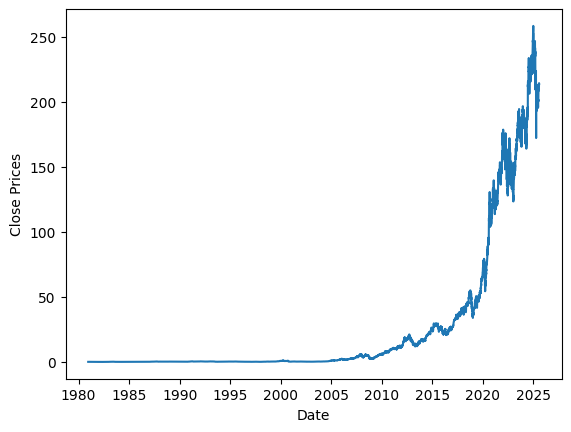

In [60]:
data = df['Close'].copy()

plt.plot(data, label='Close Prices')
plt.xlabel('Date')
plt.ylabel('Close Prices')
plt.show()

In [61]:
# Chia dữ liệu 90/10
split_index = int(len(data) * 0.9)
train = data[:split_index]
test = data[split_index:]

# Hàm đánh giá mô hình
def evaluate_model(model_name, model_func):
    model = model_func(train)
    forecast = model.forecast(len(test))
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(test, forecast),
        "RMSE": np.sqrt(mean_squared_error(test, forecast)),
        "MSE": mean_squared_error(test, forecast),
        "MAPE": mean_absolute_percentage_error(test, forecast),
        "R2 Score": r2_score(test, forecast)
    }

# Đánh giá các mô hình
results = [
    evaluate_model("Simple Exponential Smoothing", lambda data: SimpleExpSmoothing(data).fit()),
    evaluate_model("Holt Linear", lambda data: Holt(data).fit()),
    evaluate_model("Holt-Winters (no seasonal)", lambda data: ExponentialSmoothing(data, trend='add', seasonal=None).fit()),
    evaluate_model("Holt-Winters (seasonal multiplicative)", lambda data: ExponentialSmoothing(data, trend='add', seasonal='mul', seasonal_periods=252).fit())
]

# Tạo DataFrame kết quả
results_df = pd.DataFrame(results)

In [62]:
results_df

,Model,MAE,RMSE,MSE,MAPE,R2 Score
0,Simple Exponential Smoothing,42.042319,52.660651,2773.144197,0.216867,-1.415560
1,Holt Linear,61.594397,70.368128,4951.673430,0.347415,-3.313178
2,Holt-Winters (no seasonal),61.556705,70.325757,4945.712116,0.347212,-3.307985
3,Holt-Winters (seasonal multiplicative),15.695236,19.516122,380.879033,0.093699,0.668234


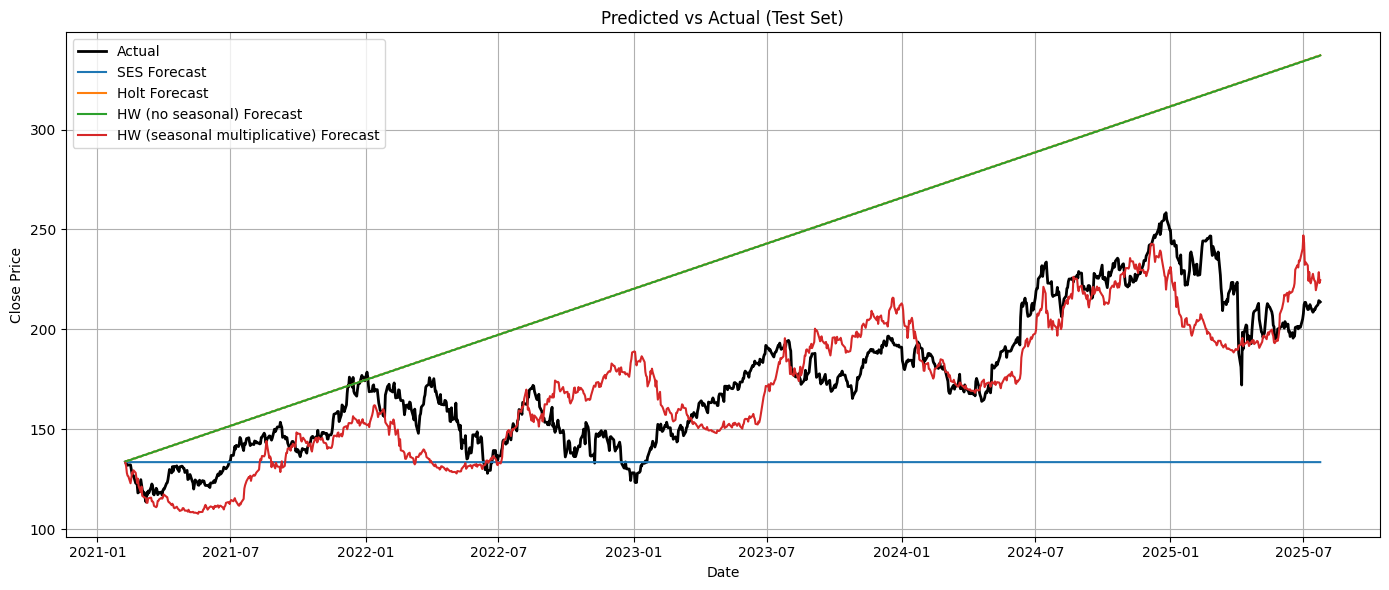

In [63]:
import matplotlib.pyplot as plt

# Dự báo từ 4 mô hình
pred_ses = SimpleExpSmoothing(train).fit().forecast(len(test))
pred_holt = Holt(train).fit().forecast(len(test))
pred_hw_no_season = ExponentialSmoothing(train, trend='add', seasonal=None).fit().forecast(len(test))
pred_hw_season_mul = ExponentialSmoothing(train, trend='add', seasonal='mul', seasonal_periods=252).fit().forecast(len(test))

# Vẽ biểu đồ
plt.figure(figsize=(14, 6))
plt.plot(test.index, test.values, label='Actual', color='black', linewidth=2)
plt.plot(test.index, pred_ses, label='SES Forecast')
plt.plot(test.index, pred_holt, label='Holt Forecast')
plt.plot(test.index, pred_hw_no_season, label='HW (no seasonal) Forecast')
plt.plot(test.index, pred_hw_season_mul, label='HW (seasonal multiplicative) Forecast')

plt.title('Predicted vs Actual (Test Set)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
